# Lecture 10: Word Embeddings and Word2Vec
## Beginner PyTorch Notebook

This notebook continues directly from the six-sentence corpus in Lecture 09.

- We use the **same corpus and vocabulary rule** as Lecture 09.
- We do **not** define a custom Python `class`.
- We do **not** define a custom `def` function.
- We use built-in PyTorch layers: `nn.Embedding` and `nn.Linear`.
- We train small CBOW and Skip-gram models with full softmax.
- The corpus is very small, so the results are only a classroom demonstration.



## Practice Problem

**Scenario:** Use the same new four-sentence corpus as the Lecture 09
practice problem:

```python
corpus_p = [
    "Noah walks a dog in the park.",
    "Mia walks a cat in the park.",
    "Emma feeds a bird in the garden.",
    "Liam feeds a fish in the garden.",
]
```

Using the **same method** as this lecture, do the following:

1. Clean, tokenize, and build a vocabulary (same steps as Lecture 09).
2. Remove the periods to build a word-only corpus.
3. Build CBOW context/target pairs with `context_offsets = [-2, -1, 1, 2]`.
4. Train a tiny CBOW model (`WORD2VEC_DIM=8`, `EPOCHS=600`, `lr=0.03`)
   with `nn.Embedding` + `nn.Linear` + `F.cross_entropy`.
5. Report the first and final training loss.
6. Compute the cosine similarity between `("dog", "cat")`,
   `("bird", "fish")`, and `("dog", "bird")`, and confirm that words
   used after the same verb end up with higher similarity than words
   used after different verbs.


### Solution

Vocabulary size: 20
CBOW context shape: (28, 4)
CBOW first loss: 3.216799
CBOW final loss: 0.297583

cosine(dog, cat) = 0.9273
cosine(bird, fish) = 0.6648
cosine(dog, bird) = 0.4842


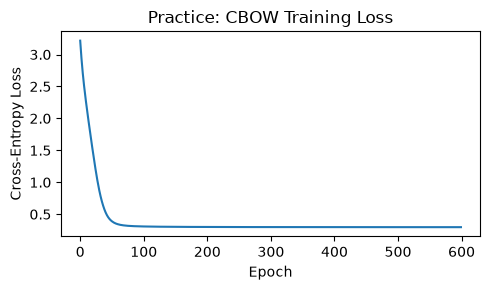

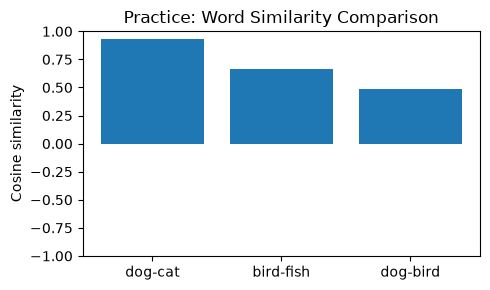

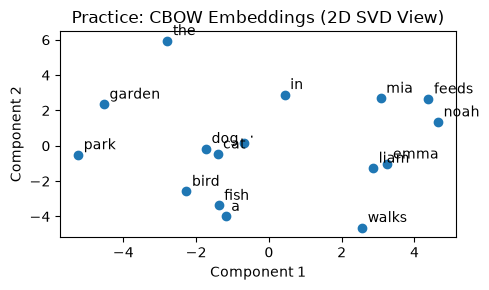

In [1]:
import matplotlib.pyplot as plt

import re
import torch
from torch import nn
import torch.nn.functional as F

SEED = 42
torch.manual_seed(SEED)
torch.set_num_threads(1)


# ----- New corpus -----
corpus_p = [
    "Noah walks a dog in the park.",
    "Mia walks a cat in the park.",
    "Emma feeds a bird in the garden.",
    "Liam feeds a fish in the garden.",
]

# ----- Clean and tokenize -----
token_pattern_p = r"[a-z]+|[.]"
cleaned_corpus_p = []
tokenized_corpus_p = []
for sentence in corpus_p:
    cleaned = re.sub(r"\s+", " ", sentence.strip().lower())
    tokens = re.findall(token_pattern_p, cleaned)
    cleaned_corpus_p.append(cleaned)
    tokenized_corpus_p.append(tokens)

# ----- Build the vocabulary -----
special_tokens_p = ["<PAD>", "<UNK>", "<BOS>", "<EOS>"]
PAD_ID_p, UNK_ID_p, BOS_ID_p, EOS_ID_p = 0, 1, 2, 3

token_counts_p = {}
for sentence_tokens in tokenized_corpus_p:
    for token in sentence_tokens:
        if token not in token_counts_p:
            token_counts_p[token] = 0
        token_counts_p[token] += 1

ordered_tokens_p = sorted(token_counts_p.keys())
ordered_tokens_p.sort(key=token_counts_p.get, reverse=True)
vocabulary_tokens_p = special_tokens_p + ordered_tokens_p

token_to_id_p, id_to_token_p = {}, {}
for token_id, token in enumerate(vocabulary_tokens_p):
    token_to_id_p[token] = token_id
    id_to_token_p[token_id] = token

VOCAB_SIZE_p = len(vocabulary_tokens_p)
print("Vocabulary size:", VOCAB_SIZE_p)

# ----- Word-only corpus (remove periods) -----
word_only_corpus_p = []
for sentence_tokens in tokenized_corpus_p:
    words = []
    for token in sentence_tokens:
        if token != ".":
            words.append(token)
    word_only_corpus_p.append(words)

# ----- Build CBOW context/target pairs -----
context_offsets_p = [-2, -1, 1, 2]
cbow_context_rows_p = []
cbow_target_ids_p = []

for sentence_words in word_only_corpus_p:
    sentence_ids = [token_to_id_p[word] for word in sentence_words]

    for center_position, center_id in enumerate(sentence_ids):
        context_row = []
        for offset in context_offsets_p:
            context_position = center_position + offset
            if 0 <= context_position < len(sentence_ids):
                context_row.append(sentence_ids[context_position])
            else:
                context_row.append(PAD_ID_p)
        cbow_context_rows_p.append(context_row)
        cbow_target_ids_p.append(center_id)

cbow_context_tensor_p = torch.tensor(cbow_context_rows_p, dtype=torch.long)
cbow_target_tensor_p = torch.tensor(cbow_target_ids_p, dtype=torch.long)
print("CBOW context shape:", tuple(cbow_context_tensor_p.shape))

# ----- Train a tiny CBOW model -----
WORD2VEC_DIM_p = 8
EPOCHS_p = 600
LEARNING_RATE_p = 0.03

torch.manual_seed(SEED)
cbow_embedding_p = nn.Embedding(VOCAB_SIZE_p, WORD2VEC_DIM_p, padding_idx=PAD_ID_p)
cbow_output_p = nn.Linear(WORD2VEC_DIM_p, VOCAB_SIZE_p)

cbow_optimizer_p = torch.optim.Adam(
    list(cbow_embedding_p.parameters()) + list(cbow_output_p.parameters()),
    lr=LEARNING_RATE_p,
)

cbow_loss_history_p = []

for epoch in range(EPOCHS_p):
    context_vectors = cbow_embedding_p(cbow_context_tensor_p)
    valid_mask = (cbow_context_tensor_p != PAD_ID_p).unsqueeze(-1)

    context_sum = (context_vectors * valid_mask).sum(dim=1)
    valid_count = valid_mask.sum(dim=1).clamp_min(1)
    context_mean = context_sum / valid_count

    cbow_logits = cbow_output_p(context_mean)
    cbow_loss = F.cross_entropy(cbow_logits, cbow_target_tensor_p)

    cbow_optimizer_p.zero_grad()
    cbow_loss.backward()
    cbow_optimizer_p.step()

    cbow_loss_history_p.append(cbow_loss.item())

print(f"CBOW first loss: {cbow_loss_history_p[0]:.6f}")
print(f"CBOW final loss: {cbow_loss_history_p[-1]:.6f}")

# ----- Cosine similarity comparison -----
cbow_vectors_p = cbow_embedding_p.weight.detach()
comparison_pairs_p = [("dog", "cat"), ("bird", "fish"), ("dog", "bird")]

print()
for word_a, word_b in comparison_pairs_p:
    vector_a = F.normalize(cbow_vectors_p[token_to_id_p[word_a]], dim=0)
    vector_b = F.normalize(cbow_vectors_p[token_to_id_p[word_b]], dim=0)
    similarity = torch.dot(vector_a, vector_b).item()
    print(f"cosine({word_a}, {word_b}) = {similarity:.4f}")


# ----- Visualization 1: CBOW training loss -----
plt.figure(figsize=(5, 3))
plt.plot(cbow_loss_history_p)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Practice: CBOW Training Loss")
plt.grid(False)
plt.tight_layout()
plt.show()

# ----- Visualization 2: cosine similarity comparison -----
similarity_values_p = []
similarity_labels_p = []
for word_a, word_b in comparison_pairs_p:
    vector_a = F.normalize(cbow_vectors_p[token_to_id_p[word_a]], dim=0)
    vector_b = F.normalize(cbow_vectors_p[token_to_id_p[word_b]], dim=0)
    similarity_values_p.append(torch.dot(vector_a, vector_b).item())
    similarity_labels_p.append(f"{word_a}-{word_b}")

plt.figure(figsize=(5, 3))
plt.bar(similarity_labels_p, similarity_values_p)
plt.ylim(-1, 1)
plt.ylabel("Cosine similarity")
plt.title("Practice: Word Similarity Comparison")
plt.grid(False)
plt.tight_layout()
plt.show()

# ----- Visualization 3: 2D view of the CBOW embeddings (SVD) -----
plot_words_p = [w for w in vocabulary_tokens_p if w not in special_tokens_p]
plot_ids_p = torch.tensor([token_to_id_p[w] for w in plot_words_p])
plot_vectors_p = cbow_vectors_p[plot_ids_p]
centered_vectors_p = plot_vectors_p - plot_vectors_p.mean(dim=0, keepdim=True)
_, _, right_vectors_p = torch.linalg.svd(centered_vectors_p, full_matrices=False)
coordinates_p = centered_vectors_p @ right_vectors_p[:2].T

plt.figure(figsize=(5, 3))
plt.scatter(coordinates_p[:, 0], coordinates_p[:, 1])
for word, point in zip(plot_words_p, coordinates_p):
    plt.annotate(word, (point[0].item(), point[1].item()), xytext=(4, 4), textcoords="offset points")
plt.title("Practice: CBOW Embeddings (2D SVD View)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(False)
plt.tight_layout()
plt.show()
